Costruisce una rete neurale densa e aggiungi layer di Dropout con tasso del 30% tra i layer nascosti. Implementa inoltre una regolarizzazione L2 sui pesi del primo layer. Utilizza un callback di Early Stopping con una pazienza di 10 epoche monitorando la validation loss. Suggermento: osserva come cambia la stabilità della curva di accuratezza rispetto a un modello senza queste tecniche.

Addestramento Modello Overfit...
Addestramento Modello Regolarizzato...


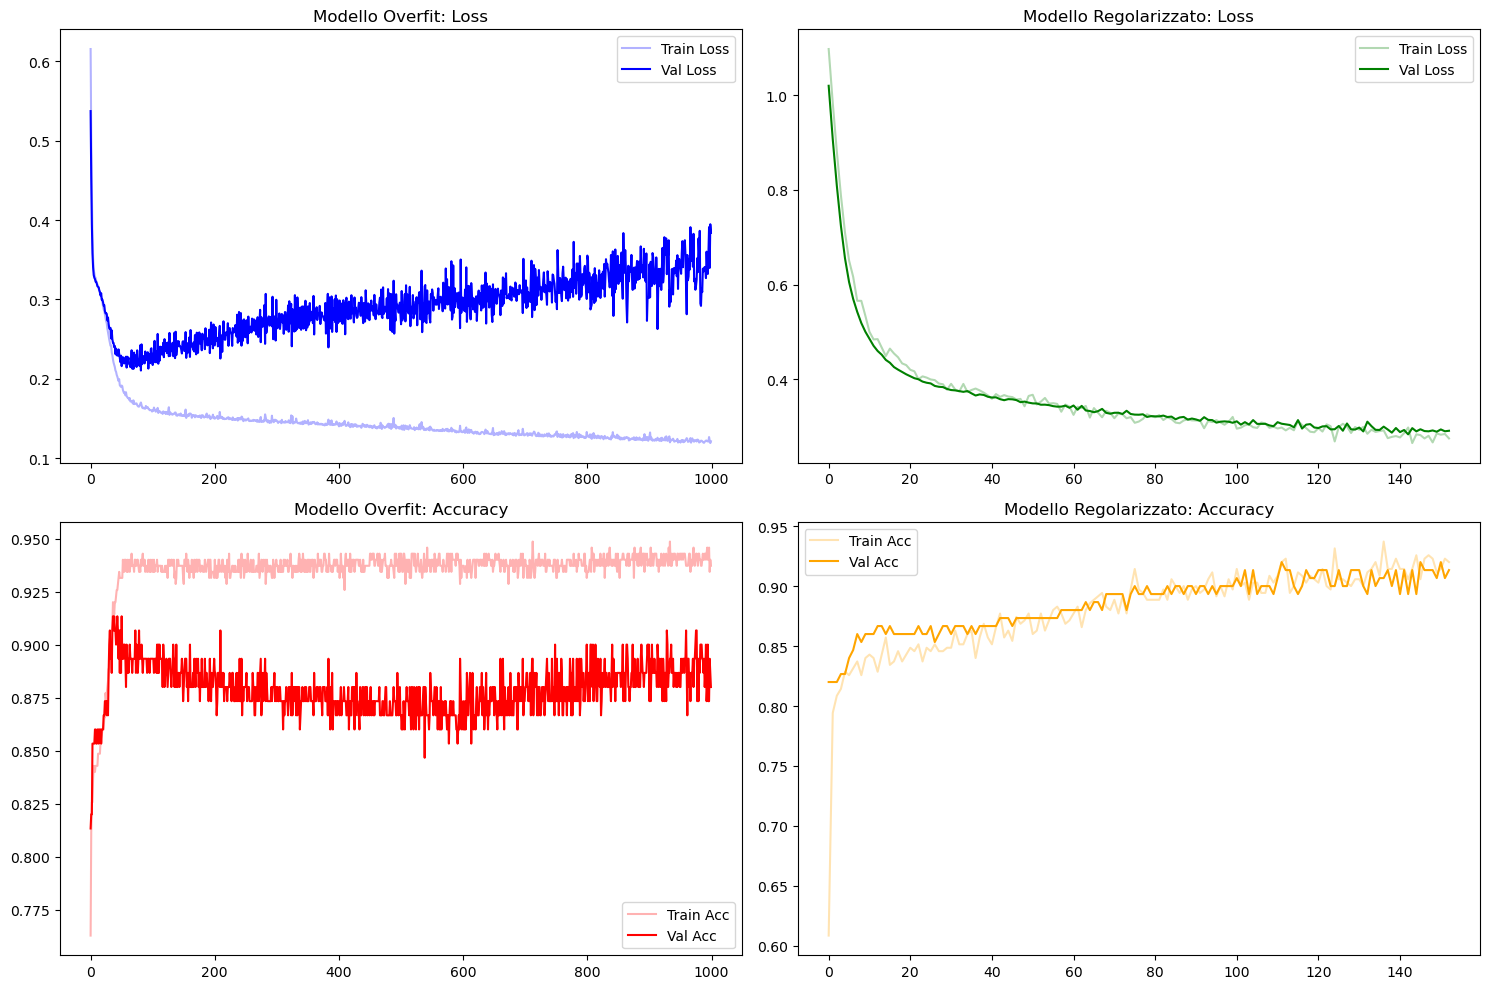

Modello Overfit terminato a epoca 200
Modello Regolarizzato terminato a epoca 153


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

# 1. GENERAZIONE DATI RUMOROSI (Dataset complesso per indurre errore)
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- MODELLO 1: OVERFITTING (Senza regolarizzazione) ---
def build_overfit_model():
    model = Sequential([
        Input(shape=(2,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid') #problema di classificazione binaria
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- MODELLO 2: REGOLARIZZATO (L2 + Dropout) ---
def build_regularized_model():
    model = Sequential([
        Input(shape=(2,)),
        # L2 Regularization: "tassa" sui pesi grandi
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        # Dropout: spegnimento casuale dei neuroni
        Dropout(0.4),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 2. CONFIGURAZIONE EARLY STOPPING
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

# 3. ADDESTRAMENTO
print("Addestramento Modello Overfit...")
model_overfit = build_overfit_model()
history_overfit = model_overfit.fit(
    X_train, y_train, epochs=1000, batch_size=32,
    validation_data=(X_test, y_test), verbose=0
)

print("Addestramento Modello Regolarizzato...")
model_reg = build_regularized_model()
history_reg = model_reg.fit(
    X_train, y_train, epochs=1000, batch_size=32,
    validation_data=(X_test, y_test), callbacks=[early_stop], verbose=0
)

# 4. VISUALIZZAZIONE COMPARATIVA
plt.figure(figsize=(15, 10))

# --- PLOT LOSS ---
plt.subplot(2, 2, 1)
plt.plot(history_overfit.history['loss'], label='Train Loss', color='blue', alpha=0.3)
plt.plot(history_overfit.history['val_loss'], label='Val Loss', color='blue')
plt.title('Modello Overfit: Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history_reg.history['loss'], label='Train Loss', color='green', alpha=0.3)
plt.plot(history_reg.history['val_loss'], label='Val Loss', color='green')
plt.title('Modello Regolarizzato: Loss')
plt.legend()

# --- PLOT ACCURACY ---
plt.subplot(2, 2, 3)
plt.plot(history_overfit.history['accuracy'], label='Train Acc', color='red', alpha=0.3)
plt.plot(history_overfit.history['val_accuracy'], label='Val Acc', color='red')
plt.title('Modello Overfit: Accuracy')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(history_reg.history['accuracy'], label='Train Acc', color='orange', alpha=0.3)
plt.plot(history_reg.history['val_accuracy'], label='Val Acc', color='orange')
plt.title('Modello Regolarizzato: Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Modello Overfit terminato a epoca 200")
print(f"Modello Regolarizzato terminato a epoca {len(history_reg.history['loss'])}")